In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install PuLP - Linear Programming library
!pip install pulp -q

import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ All libraries imported!")
print(f"PuLP version: {pulp.__version__}")

✅ All libraries imported!
PuLP version: 3.3.1


In [ ]:
# ================================================================
# BUSINESS PROBLEM: Production Planning Optimization
# ================================================================
# A furniture manufacturer produces two products:
#   - Chairs (Product A) → Profit: Rs. 500 per unit
#   - Tables (Product B) → Profit: Rs. 800 per unit
#
# Limited Resources:
#   - Labor    : 240 hours available
#   - Wood     : 270 kg available
#   - Paint    : 100 liters available
#
# Resource requirement per unit:
#   - Chair: 2 hrs labor, 3 kg wood, 1 L paint
#   - Table: 4 hrs labor, 5 kg wood, 1.5 L paint
#
# Market Demand:
#   - Max 60 chairs and 40 tables can be sold
#
# GOAL: Maximize total profit!
# ================================================================

print("=" * 55)
print("   PRODUCTION PLANNING OPTIMIZATION PROBLEM")
print("=" * 55)
print()
print("Products  : Chairs (A) and Tables (B)")
print("Objective : Maximize Profit")
print()
print("Resource        Chair   Table   Available")
print("-" * 45)
print(f"Labor (hrs)       2       4       240")
print(f"Wood  (kg)        3       5       270")
print(f"Paint (liters)    1       1.5     100")
print(f"Profit (Rs.)    500     800       —")
print("-" * 45)
print("Demand limit  : max 60 chairs, max 40 tables")

   PRODUCTION PLANNING OPTIMIZATION PROBLEM

Products  : Chairs (A) and Tables (B)
Objective : Maximize Profit

Resource        Chair   Table   Available
---------------------------------------------
Labor (hrs)       2       4       240
Wood  (kg)        3       5       270
Paint (liters)    1       1.5     100
Profit (Rs.)    500     800       —
---------------------------------------------
Demand limit  : max 60 chairs, max 40 tables


In [ ]:
# ── STEP 1: Create the problem ────────────────────────────────
problem = pulp.LpProblem("Production_Planning", pulp.LpMaximize)

# ── STEP 2: Define decision variables ─────────────────────────
# x = number of chairs to produce
# y = number of tables to produce
# lowBound=0 means we can't produce negative quantities
x = pulp.LpVariable("Chairs", lowBound=0, cat='Integer')
y = pulp.LpVariable("Tables", lowBound=0, cat='Integer')

# ── STEP 3: Set objective function ────────────────────────────
# Maximize: Total Profit = 500x + 800y
problem += 500 * x + 800 * y, "Total_Profit"

# ── STEP 4: Add constraints ───────────────────────────────────
problem += 2 * x + 4 * y <= 240,  "Labor_Hours"
problem += 3 * x + 5 * y <= 270,  "Wood_Supply"
problem += 1 * x + 1.5 * y <= 100, "Paint_Supply"
problem += x <= 60,               "Chair_Demand"
problem += y <= 40,               "Table_Demand"

print("✅ LP Model built successfully!")
print()
print("📋 Problem Formulation:")
print(problem)

✅ LP Model built successfully!

📋 Problem Formulation:
Production_Planning:
MAXIMIZE
500*Chairs + 800*Tables + 0
SUBJECT TO
Labor_Hours: 2 Chairs + 4 Tables <= 240

Wood_Supply: 3 Chairs + 5 Tables <= 270

Paint_Supply: Chairs + 1.5 Tables <= 100

Chair_Demand: Chairs <= 60

Table_Demand: Tables <= 40

VARIABLES
0 <= Chairs Integer
0 <= Tables Integer



In [ ]:
# Solve the problem using CBC solver (free & powerful)
status = problem.solve(pulp.PULP_CBC_CMD(msg=0))

print("=" * 50)
print("        🔍 OPTIMIZATION RESULTS")
print("=" * 50)
print(f"  Solver Status    : {pulp.LpStatus[status]}")
print()
print(f"  🪑 Chairs to produce : {int(pulp.value(x))} units")
print(f"  🪑 Tables to produce : {int(pulp.value(y))} units")
print(f"  💰 Maximum Profit    : Rs. {pulp.value(problem.objective):,.0f}")
print("=" * 50)

        🔍 OPTIMIZATION RESULTS
  Solver Status    : Optimal

  🪑 Chairs to produce : 60 units
  🪑 Tables to produce : 18 units
  💰 Maximum Profit    : Rs. 44,400


In [ ]:
# Get optimal values
chairs = int(pulp.value(x))
tables = int(pulp.value(y))

# Calculate actual resource usage
labor_used  = 2 * chairs + 4 * tables
wood_used   = 3 * chairs + 5 * tables
paint_used  = 1 * chairs + 1.5 * tables

# Create summary table
data = {
    'Resource'  : ['Labor (hrs)', 'Wood (kg)', 'Paint (liters)'],
    'Available' : [240, 270, 100],
    'Used'      : [labor_used, wood_used, paint_used],
    'Remaining' : [240-labor_used, 270-wood_used, 100-paint_used],
    'Usage %'   : [
        f"{(labor_used/240)*100:.1f}%",
        f"{(wood_used/270)*100:.1f}%",
        f"{(paint_used/100)*100:.1f}%"
    ]
}

df_resources = pd.DataFrame(data)

print("📊 Resource Utilization Summary:")
print("=" * 55)
print(df_resources.to_string(index=False))
print("=" * 55)
print()
print(f"  Total units produced : {chairs + tables} units")
print(f"  Chairs               : {chairs} units × Rs.500 = Rs.{chairs*500:,}")
print(f"  Tables               : {tables} units × Rs.800 = Rs.{tables*800:,}")
print(f"  Total Profit         : Rs.{chairs*500 + tables*800:,}")

📊 Resource Utilization Summary:
      Resource  Available  Used  Remaining Usage %
   Labor (hrs)        240 192.0       48.0   80.0%
     Wood (kg)        270 270.0        0.0  100.0%
Paint (liters)        100  87.0       13.0   87.0%

  Total units produced : 78 units
  Chairs               : 60 units × Rs.500 = Rs.30,000
  Tables               : 18 units × Rs.800 = Rs.14,400
  Total Profit         : Rs.44,400


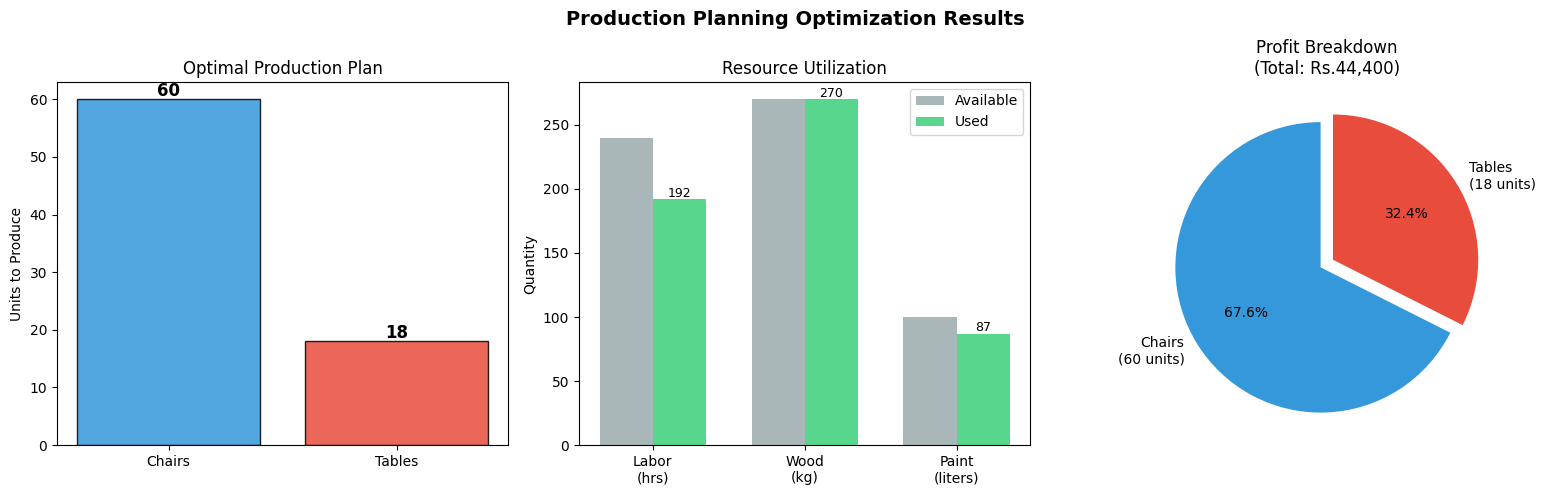

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Production Planning Optimization Results',
             fontsize=14, fontweight='bold')

# ── Chart 1: Optimal Production Plan ──────────────────────────
products = ['Chairs', 'Tables']
units    = [chairs, tables]
profits  = [chairs*500, tables*800]
colors   = ['#3498db', '#e74c3c']

bars = axes[0].bar(products, units, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Optimal Production Plan')
axes[0].set_ylabel('Units to Produce')
for bar, u in zip(bars, units):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(u), ha='center', fontweight='bold', fontsize=12)

# ── Chart 2: Resource Utilization ─────────────────────────────
resources  = ['Labor\n(hrs)', 'Wood\n(kg)', 'Paint\n(liters)']
available  = [240, 270, 100]
used       = [labor_used, wood_used, paint_used]
x_pos      = np.arange(len(resources))
width      = 0.35

bars1 = axes[1].bar(x_pos - width/2, available, width,
                     label='Available', color='#95a5a6', alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, used, width,
                     label='Used', color='#2ecc71', alpha=0.8)
axes[1].set_title('Resource Utilization')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(resources)
axes[1].set_ylabel('Quantity')
axes[1].legend()
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(int(bar.get_height())),
                 ha='center', fontsize=9)

# ── Chart 3: Profit Breakdown ──────────────────────────────────
labels  = [f'Chairs\n({chairs} units)', f'Tables\n({tables} units)']
sizes   = [chairs*500, tables*800]
explode = (0.05, 0.05)
axes[2].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'],
            explode=explode, startangle=90,
            textprops={'fontsize': 10})
axes[2].set_title(f'Profit Breakdown\n(Total: Rs.{chairs*500+tables*800:,})')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodTech_Internship/optimization_results.png', dpi=150, bbox_inches='tight')

In [ ]:
print("=" * 55)
print("       📊 OPTIMIZATION INSIGHTS")
print("=" * 55)
print()
print("🔑 Key Findings:")
print(f"   Optimal chairs : {chairs} units")
print(f"   Optimal tables : {tables} units")
print(f"   Maximum profit : Rs. {chairs*500+tables*800:,}")
print()
print("📌 Binding Constraint:")
print("   Wood supply is 100% utilized — this is the")
print("   limiting factor. Adding more wood would")
print("   allow higher production and more profit!")
print()
print("💡 Business Insights:")
print("   1. Produce at maximum chair demand (60 units)")
print("   2. Tables are limited by wood availability")
print("   3. Labor has 48 hrs slack — not a bottleneck")
print("   4. Paint has 13L slack — not a bottleneck")
print("   5. Investing in more wood = direct profit gain")
print()
print("=" * 55)
print("   🎉 TASK 4 COMPLETE!")
print("=" * 55)

       📊 OPTIMIZATION INSIGHTS

🔑 Key Findings:
   Optimal chairs : 60 units
   Optimal tables : 18 units
   Maximum profit : Rs. 44,400

📌 Binding Constraint:
   Wood supply is 100% utilized — this is the
   limiting factor. Adding more wood would
   allow higher production and more profit!

💡 Business Insights:
   1. Produce at maximum chair demand (60 units)
   2. Tables are limited by wood availability
   3. Labor has 48 hrs slack — not a bottleneck
   4. Paint has 13L slack — not a bottleneck
   5. Investing in more wood = direct profit gain

   🎉 TASK 4 COMPLETE!
